# Analyse du meilleur modèle (Random Forest)
Ce notebook produit :
- l'importance des variables (feature importances),
- les Partial Dependence Plots (PDP) pour les variables clés,
- sauvegarde des résultats dans `models/` pour réutilisation.

In [1]:
# Cellule 1 : Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.inspection import PartialDependenceDisplay
from pathlib import Path
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [9]:
# Cellule 2 : Chargement des données et du pipeline
data_path = Path('data/predictive_maintenance_v3.csv')
model_path = Path('models/best_model.pkl')
if not data_path.exists():
    raise FileNotFoundError(f'Dataset introuvable: {data_path.resolve()}')
if not model_path.exists():
    raise FileNotFoundError(f'Modèle introuvable: {model_path.resolve()}')

df = pd.read_csv(data_path)
pipeline = joblib.load(model_path)
print('Données et pipeline chargés :', df.shape)

Données et pipeline chargés : (24042, 15)


In [10]:
# Cellule 3 : Sélection des features utilisées par le pipeline
# Ajustez cette liste si votre pipeline utilise d'autres colonnes
selected_features = [
    'vibration_rms',
    'temperature_motor',
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'hours_since_maintenance',
    'operating_mode'
]
# Vérification d'existence des colonnes
missing = [c for c in selected_features if c not in df.columns]
if missing:
    raise KeyError(f'Colonnes manquantes dans le dataset: {missing}')
X = df[selected_features].copy()
y = df['failure_within_24h'] if 'failure_within_24h' in df.columns else None
X.shape

(24042, 7)

In [11]:
# Cellule 4 : Extraire le préprocesseur et le classifieur depuis le pipeline
if 'preprocessor' in pipeline.named_steps:
    preprocessor = pipeline.named_steps['preprocessor']
else:
    # si le pipeline a une autre structure, essayez de récupérer la dernière étape comme classifieur
    preprocessor = None
classifier = pipeline.named_steps.get('classifier', pipeline)
print('Classifier:', type(classifier))
# Obtenir les noms de features après transformation (si disponible)
try:
    feature_names = preprocessor.get_feature_names_out()
    feature_names = [f.split('__')[-1] for f in feature_names]
except Exception:
    # fallback : utiliser selected_features étendus par OneHot si nécessaire
    feature_names = selected_features.copy()

print('Features utilisées (après transformation) :', len(feature_names))

Classifier: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Features utilisées (après transformation) : 9


,Feature,Importance
4,rpm,0.310766
1,temperature_motor,0.256136
0,vibration_rms,0.154344
2,current_phase_avg,0.099967
8,operating_mode_peak,0.064690
3,pressure_level,0.046626
5,hours_since_maintenance,0.045889
6,operating_mode_idle,0.011352
7,operating_mode_normal,0.010230


C:\Users\potet\AppData\Local\Temp\ipykernel_16024\2512096689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


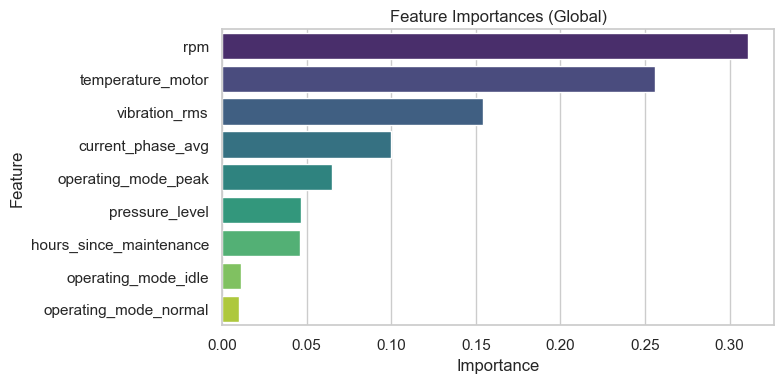

In [12]:
# Cellule 5 : Importance des variables (feature_importances_)
out_dir = Path('models')
out_dir.mkdir(exist_ok=True)
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False)
    display(fi_df.head(20))
    # Plot
    plt.figure(figsize=(8, max(4, 0.3*len(fi_df))))
    sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
    plt.title('Feature Importances (Global)')
    plt.tight_layout()
    plt.show()
    # save
    fi_df.to_csv(out_dir/'feature_importance_analysis.csv', index=False)
else:
    print('Le classifieur ne fournit pas de feature_importances_.')

In [13]:
# Cellule 6 : Partial Dependence Plots (PDP) pour les top features
from sklearn.inspection import PartialDependenceDisplay
# Choisir les 4 premières features numériques pour PDP (si présentes)
top_features = fi_df[~fi_df['Feature'].str.contains('operating', case=False)].head(4)['Feature'].tolist() if 'fi_df' in globals() else selected_features[:4]
print('Top features pour PDP:', top_features)


Top features pour PDP: ['rpm', 'temperature_motor', 'vibration_rms', 'current_phase_avg']


In [7]:
# Cellule 7 : Générer et sauvegarder les PDP en fichiers PNG, avec timer
from time import perf_counter
from pathlib import Path
out_dir = Path('models')
out_dir.mkdir(exist_ok=True)
pdp_start = perf_counter()
pdp_files = []
# Utiliser top_features déterminées précédemment (ou fallback)
pf = globals().get('top_features', selected_features[:4])
for feat in pf:
    try:
        fig, ax = plt.subplots(figsize=(6,4))
        PartialDependenceDisplay.from_estimator(pipeline, X, [feat], ax=ax)
        fname = out_dir / f'pdp_{feat}.png'
        fig.savefig(fname, bbox_inches='tight')
        pdp_files.append(str(fname))
        plt.close(fig)
    except Exception as e:
        print(f'Erreur en générant PDP pour {feat}:', e)
pdp_elapsed = perf_counter() - pdp_start
print(f'PDP sauvegardés: {pdp_files}')
print(f'Temps total PDP: {pdp_elapsed:.2f} s')

PDP sauvegardés: ['models\\pdp_rpm.png', 'models\\pdp_temperature_motor.png', 'models\\pdp_vibration_rms.png', 'models\\pdp_current_phase_avg.png']
Temps total PDP: 42.76 s


Matrice de confusion chargée
[[4018   79]
 [ 100  612]]


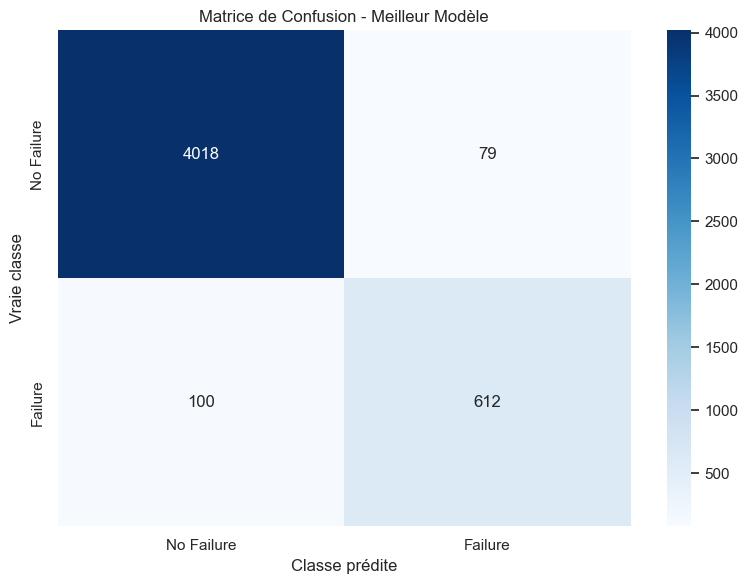

In [15]:
# Cellule 8 : Charger et afficher la matrice de confusion
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Charger la matrice de confusion précalculée
cm_path = Path('models/confusion_matrix.npy')
if cm_path.exists():
    cm = np.load(cm_path)
    print('Matrice de confusion chargée')
    print(cm)

    # Affichage avec heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.title('Matrice de Confusion - Meilleur Modèle')
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

    # Sauvegarder le plot
    plt.savefig(out_dir / 'confusion_matrix_plot.png', bbox_inches='tight')
    plt.close()
else:
    print(f'Fichier matrice de confusion non trouvé: {cm_path}')

In [ ]:
# Cellule 9 : SHAP Summary Plot
import shap
from time import perf_counter

shap_start = perf_counter()
print('Initialisation de SHAP...')

# Vérifier que le classifieur supporte SHAP (RandomForest, GradientBoosting, etc.)
clf_type = type(classifier).__name__
if clf_type in ['RandomForestClassifier', 'GradientBoostingClassifier']:
    # Préparer les données transformées
    X_transformed = pipeline.named_steps['preprocessor'].transform(X)
    
    # Créer l'explainer SHAP
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_transformed)
    
    # Si classification binaire, prendre les shap_values de la classe 1
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_transformed, feature_names=feature_names, plot_type='bar', show=False)
    plt.tight_layout()
    plt.savefig(out_dir / 'shap_summary_plot.png', bbox_inches='tight', dpi=100)
    plt.show()
    
    # Sauvegarder également un summary plot en beeswarm (si données pas trop grandes)
    if X_transformed.shape[0] < 5000:
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_vals, X_transformed, feature_names=feature_names, show=False)
        plt.tight_layout()
        plt.savefig(out_dir / 'shap_summary_beeswarm.png', bbox_inches='tight', dpi=100)
        plt.show()
    
    shap_elapsed = perf_counter() - shap_start
    print(f'SHAP calculé en {shap_elapsed:.2f} s')
else:
    print(f'SHAP non supporté pour le classifieur {clf_type}')

In [ ]:
# Cellule 10 : Courbes de dépendance (PDP et ICE plots)
from sklearn.inspection import PartialDependenceDisplay
from time import perf_counter

ice_start = perf_counter()

# Sélectionner les top 4 features numériques pour PDP/ICE
top_features_numeric = fi_df[~fi_df['Feature'].str.contains('operating', case=False)].head(4)['Feature'].tolist() if 'fi_df' in globals() else selected_features[:4]
print(f'Génération des courbes PDP/ICE pour: {top_features_numeric}')

for feat in top_features_numeric:
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # PDP (Partial Dependence Plot)
        display_pdp = PartialDependenceDisplay.from_estimator(
            pipeline, X, [feat], kind='average', ax=axes[0]
        )
        axes[0].set_title(f'PDP: {feat}')
        
        # ICE (Individual Conditional Expectation)
        display_ice = PartialDependenceDisplay.from_estimator(
            pipeline, X, [feat], kind='individual', ax=axes[1]
        )
        axes[1].set_title(f'ICE: {feat}')
        
        plt.tight_layout()
        # Sauvegarder
        fname = out_dir / f'pdp_ice_{feat}.png'
        plt.savefig(fname, bbox_inches='tight', dpi=100)
        plt.show()
        print(f'  ✓ {feat} (sauvegardé en {fname})')
    except Exception as e:
        print(f'  ✗ Erreur pour {feat}: {e}')

ice_elapsed = perf_counter() - ice_start
print(f'\nCourbes PDP/ICE générées en {ice_elapsed:.2f} s')